In [ ]:
"""You're working for a policy institute focused on SDG 13: Climate Action. You’ve already calculated correlations between three key indicators:

    CO₂ emissions per capita
    Temperature anomaly (°C)
    Deforestation rate

Now it’s time to turn those correlations into a powerful visual that decision-makers can quickly interpret — a heatmap."""

In [4]:
climate <- matrix(c(
  9.2, 1.1, 0.8,
  6.5, 0.9, 1.2,
  2.3, 0.7, 2.5,
  3.8, 1.0, 1.5,
  7.1, 1.2, 0.9
), nrow=5, byrow=TRUE)

colnames(climate) <- c("CO2", "Temp", "Deforestation")
rownames(climate) <- c("A", "B", "C", "D", "E")

scaled_climate <- scale(climate)

In [5]:
cor_matrix <- cor(scaled_climate)
print(cor_matrix)

                     CO2       Temp Deforestation
CO2            1.0000000  0.7490355    -0.9195016
Temp           0.7490355  1.0000000    -0.8976824
Deforestation -0.9195016 -0.8976824     1.0000000


In [6]:
install.packages("reshape2")  # run only once
library(reshape2)

melted <- melt(cor_matrix)
head(melted) #creates a long-format data frame where each row is a variable pair and correlation value.

Warning message:
"package 'reshape2' is in use and will not be installed"


,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,CO2,CO2,1.0000000
2,Temp,CO2,0.7490355
3,Deforestation,CO2,-0.9195016
4,CO2,Temp,0.7490355
5,Temp,Temp,1.0000000
6,Deforestation,Temp,-0.8976824


Installing package into 'C:/Users/sofoc/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\sofoc\AppData\Local\Temp\Rtmp2dtR3w\downloaded_packages


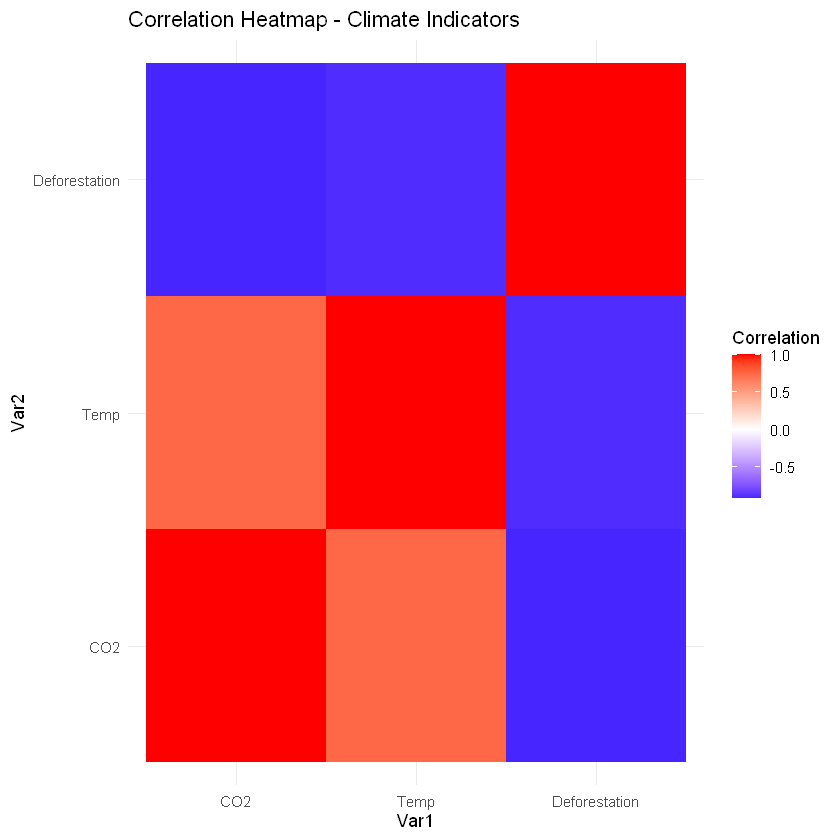

In [7]:
install.packages("ggplot2")  # run only once
library(ggplot2)

ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
  theme_minimal() +
  labs(title = "Correlation Heatmap - Climate Indicators",
       fill = "Correlation") #produce a 3×3 heatmap showing positive (red), negative (blue), and neutral (white) relationships.

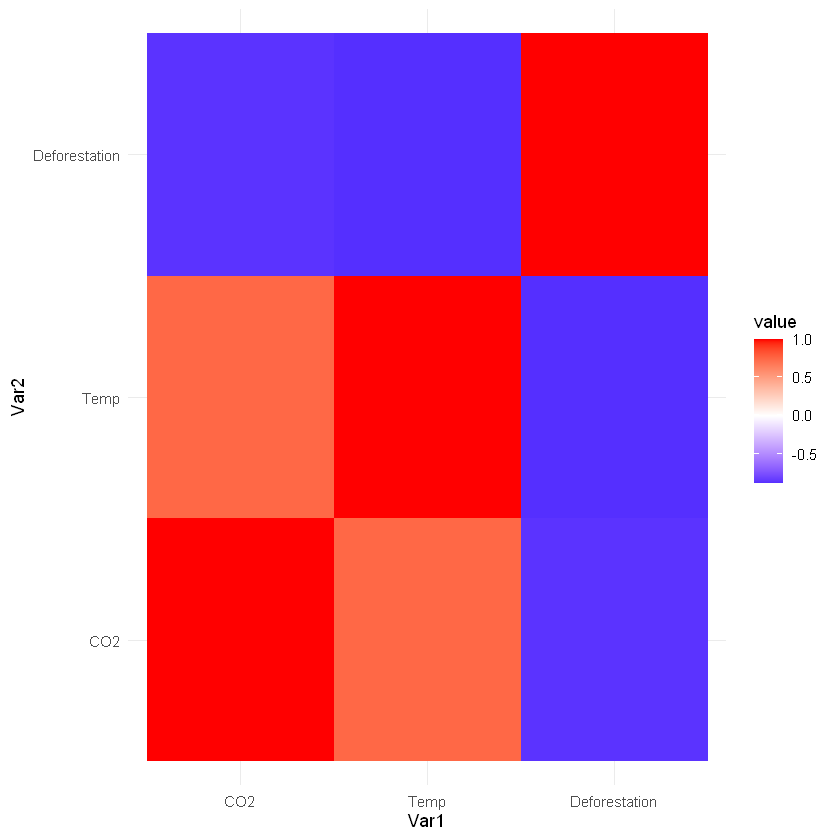

In [8]:
# Modify row 3 (Country C)
climate[3, ] <- c(2.3, 0.7, 3.2)  # higher deforestation

# Re-scale and re-plot
scaled_climate <- scale(climate)
cor_matrix <- cor(scaled_climate)
melted <- melt(cor_matrix)

ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
  theme_minimal()

In [ ]:
#Does the pattern shift? Why?
    #Deforestation <-> Temp grew a deeper blue 